<h3><b>Problem Statement</h3></b>

The entertainment industry generates massive amounts of data including Release trends, Runtime, Ratings, Revenue, Votes and categories and audience preferences. This data needs to be analysed to identify factors that contribute to a movie's commercial and critical success.

This project aims to perform Exploratory Data Analysis (EDA) on a dataset containing the top 1000 movies to uncover patterns, trends, and relationships between variables such as IMDb ratings, gross earnings, genre, runtime, release year, and audience votes.

Using Python data analysis libraries like <b>Pandas, NumPy, Matplotlib, Seaborn, and Plotly.</b><br>

The project consists of:<br>
- Importing, Cleaning & Preprocessing of dataset.
- Handling missing values and inspecting outliers.
- Visualising Trends and Distributions.
- Identifying correlations between variables.
- Deriving meaningful insights about movie performance and audience behaviour.

The analysis focuses on:

- revenue distribution patterns
- audience and critic reception
- genre-based performance
- commercial success factors
- multivariate relationships


<b> Key Business Questions: </b>

- Which genres generate the highest worldwide revenue?
- Does audience engagement correlate with box office success?
- Are highly rated movies always commercially successful?
- How have movie trends evolved over time?
- How do critic scores align with audience reception?
- What trends exist across movie releases over time?
- Which variables most strongly influence box office success?

Key findings indicate that audience engagement is more strongly associated with worldwide revenue than ratings alone, while blockbuster-driven genres such as Fantasy, Sci-Fi, and Adventure dominate commercial performance.

<b><h3> Dataset Overview </h3></b>

This Dataset displays the top 1000 highest-grossing feature films of all time as of September 5, 2022. It is in the same order as displayed on the Box Office Mojo website. (**Source:** IMDB) <br><br>

Below mentioned are the attributes of this dataset: 

Movie Title:&ensp;The name of the movie.<br>
Year of Release:&ensp;The year the movie was released.<br>
Genre:&ensp;Categories where the movie belongs.<br>
Movie Rating:&ensp;Ratings given by IMDb registered users (on a scale of 1 to 10).<br>
Duration:&ensp;Movie running time in minutes.<br>
Gross:&ensp;Gross earnings in U.S. dollars.<br>
Worldwide LT Gross:&ensp;Worldwide Lifetime Gross (International + Domestic totals).<br>
Metascore:&ensp;Weighted average of many reviews coming from reputed critics (on a scale of 0 to 100).<br>
Votes:&ensp;Number of votes cast by IMDb registered users.<br>
Logline:&ensp;A one or two sentence summary of the film.<br>

In [1]:
import pandas as pd
import numpy as np

movies = pd.read_csv('Data/top_1000_movies.csv')

<b><h3> Understanding Dataset

In [2]:
movies.head()

,Movie Title,Year of Realease,Genre,Movie Rating,Duration,Gross,Worldwide LT Gross,Metascore,Votes,Logline
0,Avatar,2009,"Action,Adventure,Fantasy",7.8,162,$760.51M,"$2,847,397,339",83,"1,236,962",A paraplegic Marine dispatched to the moon Pan...
1,Avengers: Endgame,2019,"Action,Adventure,Drama",8.4,181,$858.37M,"$2,797,501,328",78,"1,108,641",After the devastating events of Avengers: Infi...
2,Titanic,1997,"Drama,Romance",7.9,194,$659.33M,"$2,201,647,264",75,"1,162,142",A seventeen-year-old aristocrat falls in love ...
3,Star Wars: Episode VII - The Force Awakens,2015,"Action,Adventure,Sci-Fi",7.8,138,$936.66M,"$2,069,521,700",80,"925,551","As a new threat to the galaxy rises, Rey, a de..."
4,Avengers: Infinity War,2018,"Action,Adventure,Sci-Fi",8.4,149,$678.82M,"$2,048,359,754",68,"1,062,517",The Avengers and their allies must be willing ...


In [3]:
movies = movies.drop(['Duration','Logline'], axis=1, errors='ignore')
movies.head()


,Movie Title,Year of Realease,Genre,Movie Rating,Gross,Worldwide LT Gross,Metascore,Votes
0,Avatar,2009,"Action,Adventure,Fantasy",7.8,$760.51M,"$2,847,397,339",83,"1,236,962"
1,Avengers: Endgame,2019,"Action,Adventure,Drama",8.4,$858.37M,"$2,797,501,328",78,"1,108,641"
2,Titanic,1997,"Drama,Romance",7.9,$659.33M,"$2,201,647,264",75,"1,162,142"
3,Star Wars: Episode VII - The Force Awakens,2015,"Action,Adventure,Sci-Fi",7.8,$936.66M,"$2,069,521,700",80,"925,551"
4,Avengers: Infinity War,2018,"Action,Adventure,Sci-Fi",8.4,$678.82M,"$2,048,359,754",68,"1,062,517"


In [4]:
movies.shape

(1000, 8)

In [5]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Movie Title         1000 non-null   object 
 1   Year of Realease    1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Movie Rating        1000 non-null   float64
 4   Gross               1000 non-null   object 
 5   Worldwide LT Gross  1000 non-null   object 
 6   Metascore           1000 non-null   object 
 7   Votes               1000 non-null   object 
dtypes: float64(1), object(7)
memory usage: 62.6+ KB


<b><h3> Cleaning the Data

In [6]:
movies = movies.rename(columns={'Year of Realease' : 'Year of Release'})

cols_to_fix = ['Metascore', 'Votes','Worldwide LT Gross', 'Gross', 'Year of Release']

In [ ]:
def replace_str(value): 

    value = value.replace('$','')
    value = value.replace(',','')
    value = value.replace('M','')
    value = value.replace('X','')
    
    return value

In [8]:
#If applying pd.to_numeric and we come across something that it cannot parse, default behaviour is to raise Exception, you could coerce errors to fill
#them as na 

for col in cols_to_fix:
    movies[col] = pd.to_numeric(movies[col].apply(replace_str),errors='coerce')

movies['Year of Release']=movies['Year of Release'].astype('int16')
display(movies)

,Movie Title,Year of Release,Genre,Movie Rating,Gross,Worldwide LT Gross,Metascore,Votes
0,Avatar,2009,"Action,Adventure,Fantasy",7.8,760.51,2847397339,83.0,1236962
1,Avengers: Endgame,2019,"Action,Adventure,Drama",8.4,858.37,2797501328,78.0,1108641
2,Titanic,1997,"Drama,Romance",7.9,659.33,2201647264,75.0,1162142
3,Star Wars: Episode VII - The Force Awakens,2015,"Action,Adventure,Sci-Fi",7.8,936.66,2069521700,80.0,925551
4,Avengers: Infinity War,2018,"Action,Adventure,Sci-Fi",8.4,678.82,2048359754,68.0,1062517
...,...,...,...,...,...,...,...,...
995,The A-Team,2010,"Action,Adventure,Thriller",6.7,77.22,177238796,47.0,259316
996,Tootsie,1982,"Comedy,Drama,Romance",7.4,177.20,177200271,88.0,107311
997,In the Line of Fire,1993,"Action,Crime,Drama",7.2,102.31,176997168,74.0,104598
998,Analyze This,1999,"Comedy,Crime",6.7,106.89,176885658,61.0,154726


To ensure consistency, we will rescale our key numeric columns — Gross and Worldwide LT Gross will be converted to millions, <br> Both Movie Rating and Metascore will be expressed on a scale out of 10.

In [9]:
movies['Worldwide LT Gross'] = (movies['Worldwide LT Gross'] / 1000000).astype(float).round(2)
movies['Metascore'] = movies['Metascore'] / 10

movies

,Movie Title,Year of Release,Genre,Movie Rating,Gross,Worldwide LT Gross,Metascore,Votes
0,Avatar,2009,"Action,Adventure,Fantasy",7.8,760.51,2847.40,8.3,1236962
1,Avengers: Endgame,2019,"Action,Adventure,Drama",8.4,858.37,2797.50,7.8,1108641
2,Titanic,1997,"Drama,Romance",7.9,659.33,2201.65,7.5,1162142
3,Star Wars: Episode VII - The Force Awakens,2015,"Action,Adventure,Sci-Fi",7.8,936.66,2069.52,8.0,925551
4,Avengers: Infinity War,2018,"Action,Adventure,Sci-Fi",8.4,678.82,2048.36,6.8,1062517
...,...,...,...,...,...,...,...,...
995,The A-Team,2010,"Action,Adventure,Thriller",6.7,77.22,177.24,4.7,259316
996,Tootsie,1982,"Comedy,Drama,Romance",7.4,177.20,177.20,8.8,107311
997,In the Line of Fire,1993,"Action,Crime,Drama",7.2,102.31,177.00,7.4,104598
998,Analyze This,1999,"Comedy,Crime",6.7,106.89,176.89,6.1,154726


- Type Conversion on numeric columns and cleaned financial values, removed symbols to make the data ready for statistical analysis and visualisation.
- Rescaled Revenue into millions to have a standard and improve interpretability.


In [10]:
movies.describe()

,Year of Release,Movie Rating,Gross,Worldwide LT Gross,Metascore,Votes
count,1000.000000,1000.00000,966.000000,1000.000000,964.000000,1.000000e+03
mean,2007.611000,6.80080,156.158975,410.597630,5.964419,3.393784e+05
std,10.398067,0.90145,110.629617,295.192811,1.594692,3.231349e+05
min,1937.000000,2.50000,0.010000,176.600000,1.200000,3.960000e+02
25%,2002.000000,6.20000,90.832500,222.032500,4.800000,1.347940e+05
50%,2010.000000,6.80000,129.245000,308.410000,5.900000,2.448125e+05
75%,2016.000000,7.40000,187.090000,473.342500,7.100000,4.410002e+05
max,2022.000000,9.20000,936.660000,2847.400000,10.000000,2.622926e+06


In [11]:
movies[movies.duplicated(subset=['Movie Title', 'Year of Release'])]

,Movie Title,Year of Release,Genre,Movie Rating,Gross,Worldwide LT Gross,Metascore,Votes


<b><h3> Handling Null Values

In [12]:
# Check if any of the rows have na (even one row as na)
movies.isna().any()

Movie Title           False
Year of Release       False
Genre                 False
Movie Rating          False
Gross                  True
Worldwide LT Gross    False
Metascore              True
Votes                 False
dtype: bool

In [13]:
movies[movies['Gross'].isna()].shape[0]/len(movies)*100

3.4000000000000004

In [14]:
# Remove missing data since its only 3.4% of the total data
for i in movies.columns:
    print(movies[i].isna().value_counts())

Movie Title
False    1000
Name: count, dtype: int64
Year of Release
False    1000
Name: count, dtype: int64
Genre
False    1000
Name: count, dtype: int64
Movie Rating
False    1000
Name: count, dtype: int64
Gross
False    966
True      34
Name: count, dtype: int64
Worldwide LT Gross
False    1000
Name: count, dtype: int64
Metascore
False    964
True      36
Name: count, dtype: int64
Votes
False    1000
Name: count, dtype: int64


In [15]:
movies.skew(numeric_only=True)

Year of Release      -1.558734
Movie Rating         -0.273018
Gross                 2.290571
Worldwide LT Gross    2.906042
Metascore             0.073277
Votes                 2.419748
dtype: float64

In [16]:
# movies.fillna(0,inplace=True)
movies['Gross'] = movies['Gross'].fillna(movies['Gross'].median())
movies['Metascore'] = movies['Metascore'].fillna(movies['Metascore'].median())

fill NA values with median because data is highly skewed so mean will be affected due to outliers and extreme values, median will be more stable

In [17]:
# No more na values left
movies.isna().value_counts()

Movie Title  Year of Release  Genre  Movie Rating  Gross  Worldwide LT Gross  Metascore  Votes
False        False            False  False         False  False               False      False    1000
Name: count, dtype: int64

- Median Imputaion is used for Metascore and Gross columns to handle NA values because these distributions were highly skewed.<br>
- Mean imputaion would have caused resulted data to be disproportionate and highly influenced by the revenue of the few blockbuster movies.

<b><h3> Univariate Analysis

In [18]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [19]:
movies['Gross'].nsmallest(5)
movies['Movie Rating'].nlargest(5)

646    9.2
25     9.0
49     9.0
469    9.0
794    8.9
Name: Movie Rating, dtype: float64

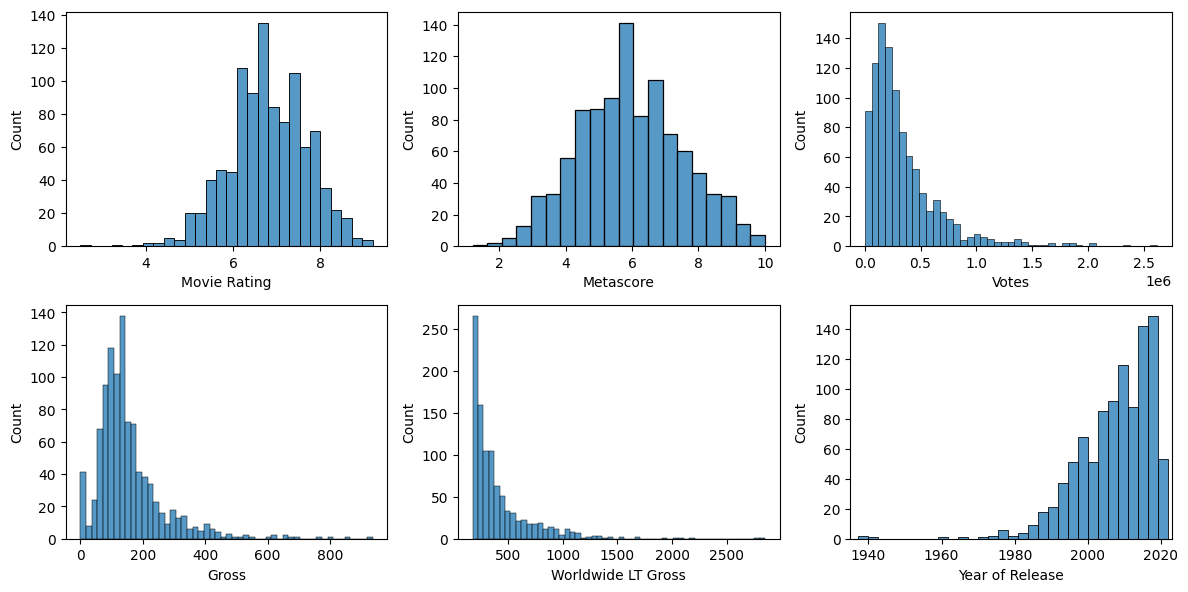

In [20]:
# Histogram — distribution of one column
uni_hist, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,6))
f1 = sns.histplot(data=movies, x='Movie Rating', ax=axes[0,0])
f2 = sns.histplot(data=movies, x='Metascore', ax=axes[0,1])
f3 = sns.histplot(data=movies, x='Gross', ax=axes[1,0])
f4 = sns.histplot(data=movies, x='Worldwide LT Gross', ax=axes[1,1])
f5 = sns.histplot(data=movies, x='Votes', ax=axes[0,2])
f6 = sns.histplot(data=movies, x='Year of Release', ax=axes[1,2])
axes[1,2].set_xlim(1935,2023)

uni_hist.tight_layout()


Interpretation:
- Gross, Worldwide LT Gross and Votes are heavily right skewed
- YOR is left skewed

Meaning:
- Few movies contribute to extremely high earnings (Goss & LT Gross)
- Few movies dominate the popularity (Votes)

- Most movies tend to have an average rating but few Blockbuster movies dominate and highly influence the data across popularity, and revenue. It is also important to note that the data at hand lacks older movies, that are comparatively underrepresented, this indicates a sampling bias or maybe the data for them was not accessible.

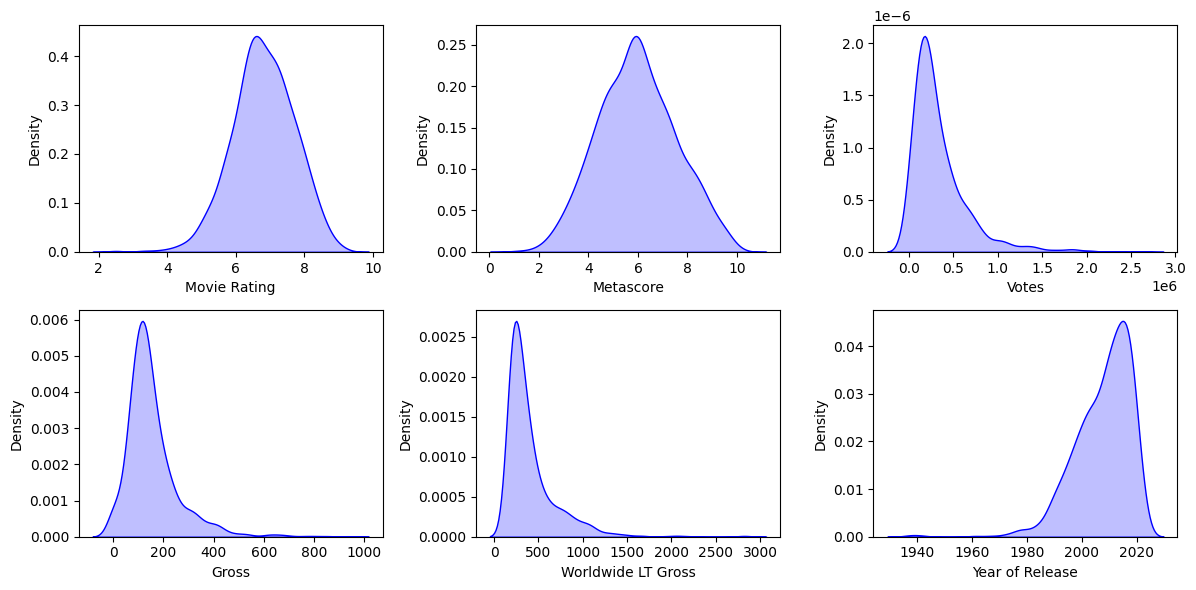

In [21]:
uni_kde, axes = plt.subplots(nrows=2,ncols=3, figsize=(12,6))

f1 = sns.kdeplot(data=movies, x='Movie Rating', color='blue', fill='blue', ax=axes[0,0])
f2 = sns.kdeplot(data=movies, x='Metascore', color='blue', fill='blue', ax=axes[0,1])
f3 = sns.kdeplot(data=movies, x='Gross', color='blue', fill='blue', ax=axes[1,0])
f4 = sns.kdeplot(data=movies, x='Worldwide LT Gross', color='blue', fill='blue', ax=axes[1,1])
f5 = sns.kdeplot(data=movies, x='Votes', color='blue', fill='blue', ax=axes[0,2])
f6 = sns.kdeplot(data=movies, x='Year of Release', color='blue', fill='blue', ax=axes[1,2])

uni_kde.tight_layout()

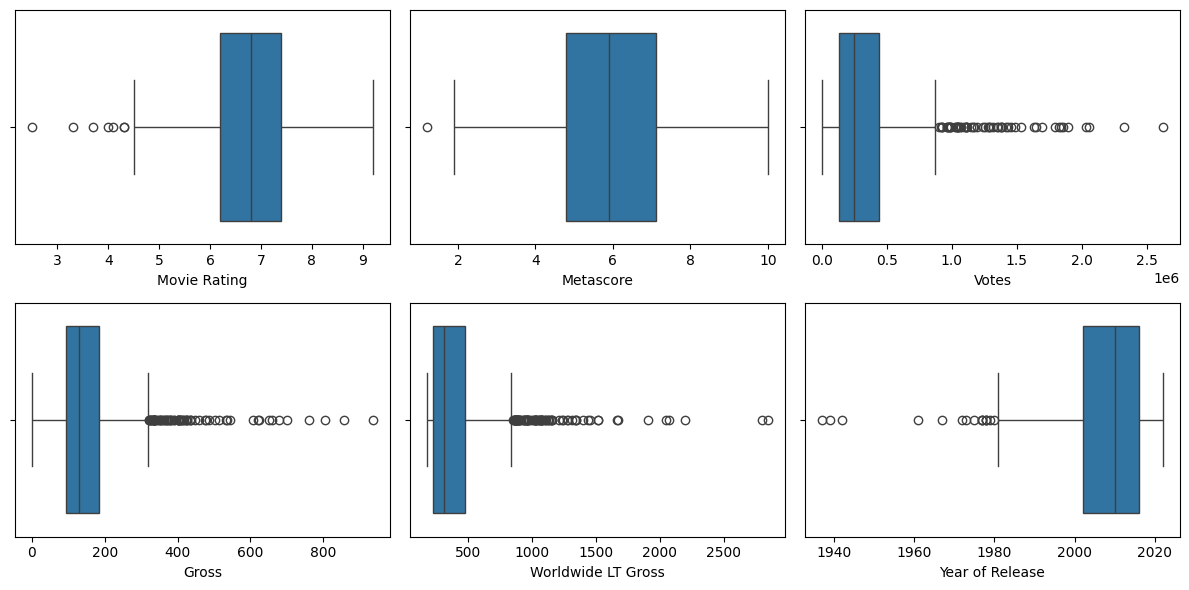

In [22]:
uni_box, axes = plt.subplots(nrows=2,ncols=3, figsize=(12,6))

f1 = sns.boxplot(data=movies, x='Movie Rating', ax=axes[0,0])
f2 = sns.boxplot(data=movies, x='Metascore', ax=axes[0,1])
f3 = sns.boxplot(data=movies, x='Gross', ax=axes[1,0])
f4 = sns.boxplot(data=movies, x='Worldwide LT Gross', ax=axes[1,1])
f5 = sns.boxplot(data=movies, x='Votes', ax=axes[0,2])
f6 = sns.boxplot(data=movies, x='Year of Release', ax=axes[1,2])

uni_box.tight_layout()

- The outliers in Gross and Votes correspond to globally successful films that significantly exceed industry averages.

- The presence of outliers in entertainment industry is expected because of the nature of the industry, dominated by exceptional successes. Hence, the outliers are valuable data points and not just bad data.

In [23]:
movies.skew(numeric_only=True)

Year of Release      -1.558734
Movie Rating         -0.273018
Gross                 2.348143
Worldwide LT Gross    2.906042
Metascore             0.079072
Votes                 2.419748
dtype: float64

- skewness >1 is highly Right skewed
- skewness <-1 is highly Left skewed

In [ ]:
top_10_highest_grossing = movies[["Movie Title","Worldwide LT Gross",'Year of Release']].sort_values(by=["Worldwide LT Gross"], ascending=False).head(10)
print(plt.style.available)
print(sns.set_theme())


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
None


In [ ]:

f1= px.bar(top_10_highest_grossing, x='Worldwide LT Gross', y='Movie Title',
        orientation='h',
        color='Year of Release',
        )

f1.update_layout(
        yaxis={'categoryorder':'total ascending'},
        title={
            'text':'Top 10 Highest Grossing Movies',
            'x':0.5,
        }
)


In [26]:
top_10_most_votes = movies[["Movie Title","Votes",'Year of Release']].sort_values(by=["Votes"], ascending=False).head(10)

In [ ]:
f1= px.bar(top_10_most_votes, x='Votes', y='Movie Title',
        orientation='h',
        color='Year of Release',
        )

f1.update_layout(
        yaxis={'categoryorder':'total ascending'},
        title={
            'text':'Top 10 Most Voted Movies',
            'x':0.5,
        }
)

<b><h3> Bivariate Analysis

<h4>A. Correlation Analysis & Scatter Plots

In [31]:
# Correlation Matrix Method

movies.corr(numeric_only=True)

,Year of Release,Movie Rating,Gross,Worldwide LT Gross,Metascore,Votes
Year of Release,1.000000,-0.169094,0.015702,0.197252,-0.147527,-0.104165
Movie Rating,-0.169094,1.000000,0.308437,0.250941,0.750845,0.655254
Gross,0.015702,0.308437,1.000000,0.844607,0.272487,0.492849
Worldwide LT Gross,0.197252,0.250941,0.844607,1.000000,0.201618,0.425986
Metascore,-0.147527,0.750845,0.272487,0.201618,1.000000,0.458921
Votes,-0.104165,0.655254,0.492849,0.425986,0.458921,1.000000


<Axes: >

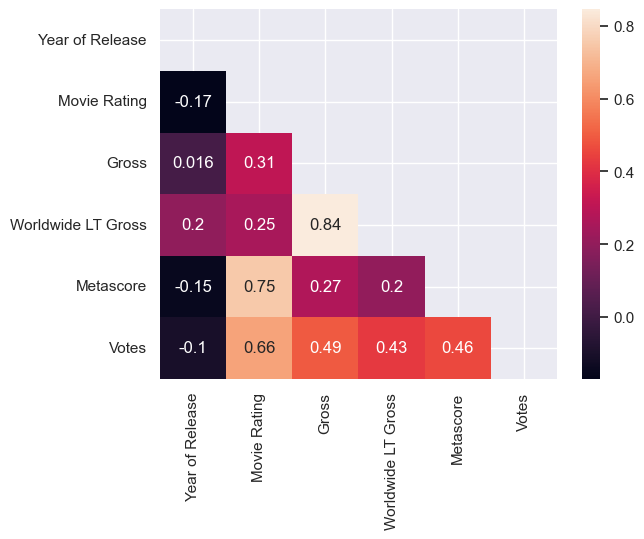

In [32]:
# Visualisation of Correlation Matrix 

mask = np.triu(np.ones_like(movies.corr(numeric_only=True)))
sns.heatmap(movies.corr(numeric_only=True), annot=True, mask=mask)

- Stong correlation between Worldwide LT Gross & Gross, which is kinda obvious: both show revenue
- Strong COrrelation in Movie Ratings and Metascore: both are Ratings
- Votes (Audience engagement) have the highest correlation with Revenue & Ratings

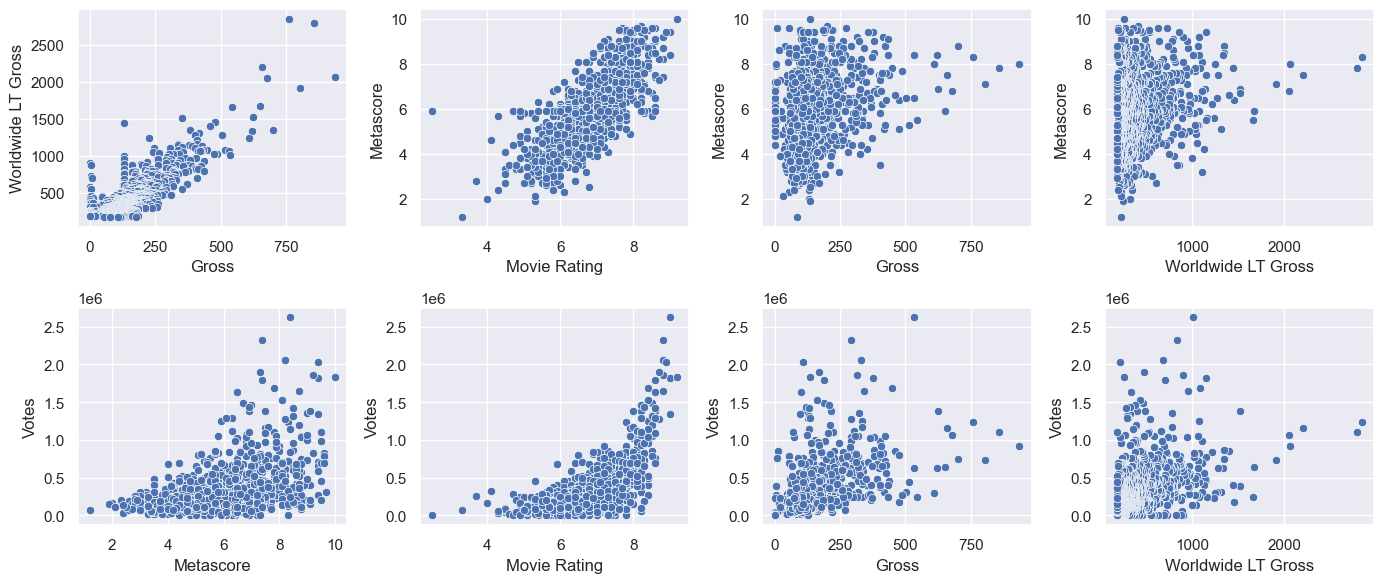

In [33]:
fig,axes=plt.subplots(nrows=2, ncols=4, figsize=(14,6))

f1=sns.scatterplot(movies, y='Worldwide LT Gross', x='Gross', ax=axes[0,0])
f1=sns.scatterplot(movies, y='Metascore', x='Movie Rating', ax=axes[0,1])
f1=sns.scatterplot(movies, y='Metascore', x='Gross', ax=axes[0,2])
f1=sns.scatterplot(movies, y='Metascore', x='Worldwide LT Gross', ax=axes[0,3])

f2=sns.scatterplot(movies, y='Votes', x='Metascore', ax=axes[1,0])
f2=sns.scatterplot(movies, y='Votes', x='Movie Rating', ax=axes[1,1])
f2=sns.scatterplot(movies, y='Votes', x='Gross', ax=axes[1,2])
f1=sns.scatterplot(movies, y='Votes', x='Worldwide LT Gross', ax=axes[1,3])

fig.tight_layout()


In [34]:
# sns.pairplot(
#     movies[['Gross',
#             'Worldwide LT Gross',
#             'Votes',
#             'Movie Rating',
#             'Metascore']]
# )

<b> Key Insights: </b>

1. Worldwide Gross and Gross demonstrated strong positive correlation, indicating alignment between domestic and global commercial performance.
2. Audience engagement (Votes) exhibited a stronger relationship with revenue than ratings.
3. Critic scores and audience ratings showed moderate positive correlation, suggesting partial alignment between critics and audiences.
4. Commercial success appears influenced more heavily by popularity and reach than by critical reception alone.

<h4> B. Trend Analysis: Time-Based Analysis

In [95]:
movies_trend = movies.groupby(['Year of Release']).agg(
    movie_count = ('Movie Title', 'count'),
    avg_rating = ('Movie Rating', 'median'),
    avg_metascore = ('Metascore', 'median'),
    total_gross = ('Gross', 'sum'),
    total_wlt = ('Worldwide LT Gross', 'sum'),
    total_votes = ('Votes', 'sum')
)

movies_trend.sort_values(by=['Year of Release'], ascending=False).reset_index()


,Year of Release,movie_count,avg_rating,avg_metascore,total_gross,total_wlt,total_votes
0,2022,17,6.50,5.90,2197.165,9207.41,2784801
1,2021,23,6.60,5.90,3302.065,11083.82,4753489
2,2020,13,6.60,5.90,1229.605,4074.13,1429719
3,2019,49,6.80,5.90,8552.130,26358.72,12028046
4,2018,47,6.70,6.00,8268.965,24674.90,10990514
5,2017,53,6.70,5.90,8114.335,25374.78,14070222
6,2016,53,6.70,5.90,8011.495,23299.01,15205471
7,2015,40,6.60,5.95,7350.105,21124.90,12099693
8,2014,49,6.60,5.90,7094.235,20689.75,18865646
9,2013,45,7.00,5.80,7044.540,19527.27,17887390


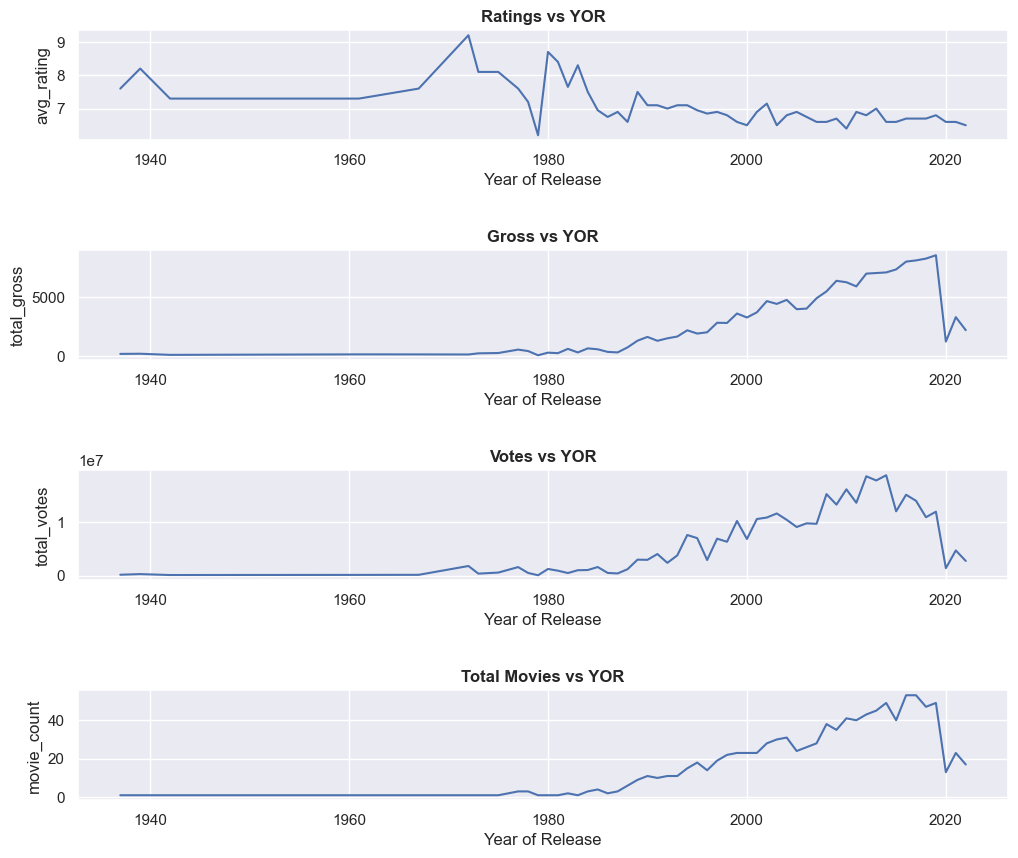

In [96]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12,10))

f1 = sns.lineplot(movies_trend, x='Year of Release', y='avg_rating', ax=axes[0])
f2 = sns.lineplot(movies_trend, x='Year of Release', y='total_gross', ax=axes[1])
f3 = sns.lineplot(movies_trend, x='Year of Release', y='total_votes', ax=axes[2])
f4 = sns.lineplot(movies_trend, x='Year of Release', y='movie_count', ax=axes[3])

f1.set_title('Ratings vs YOR',fontdict={'fontweight':'bold'})
f2.set_title('Gross vs YOR', fontdict={'fontweight':'bold'})
f3.set_title('Votes vs YOR', fontdict={'fontweight':'bold'})
f4.set_title('Total Movies vs YOR', fontdict={'fontweight':'bold'})
fig.subplots_adjust(hspace=1)
# fig.tight_layout()


<b> Key Insights: </b>

1. The dataset is dominated by movies released in recent decades, particularly after the 1990s.
2. The concentration of modern films reflects both industry expansion and the accessibility of recent data.
3. Worldwide revenue trends generally increased over time, likely influenced by globalization, growth, and larger international audiences.
4. Audience engagement appears substantially higher for recent films, potentially due to internet accessibility and online rating platforms.

<h4> C. Category Based: Genre-wise Analysis

In [35]:
movies

,Movie Title,Year of Release,Genre,Movie Rating,Gross,Worldwide LT Gross,Metascore,Votes
0,Avatar,2009,"Action,Adventure,Fantasy",7.8,760.51,2847.40,8.3,1236962
1,Avengers: Endgame,2019,"Action,Adventure,Drama",8.4,858.37,2797.50,7.8,1108641
2,Titanic,1997,"Drama,Romance",7.9,659.33,2201.65,7.5,1162142
3,Star Wars: Episode VII - The Force Awakens,2015,"Action,Adventure,Sci-Fi",7.8,936.66,2069.52,8.0,925551
4,Avengers: Infinity War,2018,"Action,Adventure,Sci-Fi",8.4,678.82,2048.36,6.8,1062517
...,...,...,...,...,...,...,...,...
995,The A-Team,2010,"Action,Adventure,Thriller",6.7,77.22,177.24,4.7,259316
996,Tootsie,1982,"Comedy,Drama,Romance",7.4,177.20,177.20,8.8,107311
997,In the Line of Fire,1993,"Action,Crime,Drama",7.2,102.31,177.00,7.4,104598
998,Analyze This,1999,"Comedy,Crime",6.7,106.89,176.89,6.1,154726


In [36]:
movies[['Genre A', 'Genre B', 'Genre C']] = movies['Genre'].str.split(',', expand = True).iloc[ : , :3]
movies.drop(columns='Genre', inplace=True)
movies

,Movie Title,Year of Release,Movie Rating,Gross,Worldwide LT Gross,Metascore,Votes,Genre A,Genre B,Genre C
0,Avatar,2009,7.8,760.51,2847.40,8.3,1236962,Action,Adventure,Fantasy
1,Avengers: Endgame,2019,8.4,858.37,2797.50,7.8,1108641,Action,Adventure,Drama
2,Titanic,1997,7.9,659.33,2201.65,7.5,1162142,Drama,Romance,None
3,Star Wars: Episode VII - The Force Awakens,2015,7.8,936.66,2069.52,8.0,925551,Action,Adventure,Sci-Fi
4,Avengers: Infinity War,2018,8.4,678.82,2048.36,6.8,1062517,Action,Adventure,Sci-Fi
...,...,...,...,...,...,...,...,...,...,...
995,The A-Team,2010,6.7,77.22,177.24,4.7,259316,Action,Adventure,Thriller
996,Tootsie,1982,7.4,177.20,177.20,8.8,107311,Comedy,Drama,Romance
997,In the Line of Fire,1993,7.2,102.31,177.00,7.4,104598,Action,Crime,Drama
998,Analyze This,1999,6.7,106.89,176.89,6.1,154726,Comedy,Crime,None


In [37]:
movies_long = movies.melt(id_vars=['Movie Title', 'Year of Release', 'Movie Rating', 'Metascore', 'Votes', 'Gross', 'Worldwide LT Gross'],
                          value_vars=['Genre A', 'Genre B', 'Genre C'], var_name='genre type', value_name='Genre')


In [38]:
print(movies_long['Genre'].unique())
print(type(movies_long['Genre'].iloc[-1]))

# None value is python None and idk why it says str here

['Action' 'Drama' 'Animation' 'Adventure' 'Crime' 'Biography' 'Comedy'
 'Mystery' 'Horror' 'Documentary' 'Fantasy' 'Romance' 'Family' 'Thriller'
 'Sci-Fi' None 'Musical' 'History' 'War' 'Music' 'Western' 'Sport']
<class 'str'>


In [39]:
movies_long = movies_long.dropna(subset=['Genre'])
movies_long = movies_long.reset_index()

In [40]:
movies_long

,index,Movie Title,Year of Release,Movie Rating,Metascore,Votes,Gross,Worldwide LT Gross,genre type,Genre
0,0,Avatar,2009,7.8,8.3,1236962,760.51,2847.40,Genre A,Action
1,1,Avengers: Endgame,2019,8.4,7.8,1108641,858.37,2797.50,Genre A,Action
2,2,Titanic,1997,7.9,7.5,1162142,659.33,2201.65,Genre A,Drama
3,3,Star Wars: Episode VII - The Force Awakens,2015,7.8,8.0,925551,936.66,2069.52,Genre A,Action
4,4,Avengers: Infinity War,2018,8.4,6.8,1062517,678.82,2048.36,Genre A,Action
...,...,...,...,...,...,...,...,...,...,...
2754,2993,The Haunting,1999,5.0,4.2,76733,91.41,177.31,Genre C,Mystery
2755,2995,The A-Team,2010,6.7,4.7,259316,77.22,177.24,Genre C,Thriller
2756,2996,Tootsie,1982,7.4,8.8,107311,177.20,177.20,Genre C,Romance
2757,2997,In the Line of Fire,1993,7.2,7.4,104598,102.31,177.00,Genre C,Drama


In [94]:
# # Violin plot — distribution shape
# f1 = px.violin(movies_long, x='Genre', y='Movie Rating')
# display(f1)

In [179]:
genre_agg = movies_long.groupby('Genre').agg(
    movie_count = ('Movie Title',  'count'),
    avg_rating  = ('Movie Rating', 'mean'),
    avg_metascore  = ('Metascore', 'mean'),
    median_gross = ('Gross',        'median'),
    median_wltgross = ('Worldwide LT Gross', 'median'),
    median_votes   = ('Votes',        'median')
).sort_values(by='movie_count', ascending=False).head(12).reset_index()

genre_agg

,Genre,movie_count,avg_rating,avg_metascore,median_gross,median_wltgross,median_votes
0,Adventure,518,6.738031,5.906757,150.685,386.320,248390.0
1,Action,472,6.725000,5.734746,131.995,352.475,283213.5
2,Comedy,384,6.590625,5.741406,129.245,275.690,180817.0
3,Drama,298,7.164765,6.567785,119.050,264.625,258885.0
4,Animation,159,6.898742,6.440252,153.710,373.520,175301.0
5,Sci-Fi,152,6.746053,5.786842,145.605,392.000,410986.0
6,Thriller,141,6.784397,5.869504,121.660,293.500,259316.0
7,Fantasy,121,6.621488,5.451240,137.360,403.450,282939.0
8,Crime,114,6.989474,6.113158,126.345,242.495,274654.5
9,Romance,98,6.762245,5.877551,117.395,241.990,208260.0


(we only include the top 12 genres as genres with less 'movie count' might distort the visualisation because of the shortage of data available for them.)

In [181]:
genre_popularity = px.bar(genre_agg, x='median_votes', y='Genre',
                         orientation='h', 
                         color='median_votes',
                         color_continuous_scale=[[0, "#22045D"], [0.5, "#8F1BC4"], [1, "#ff00d4"]],
                         title='Genre Popularity based on Votes', 
                         width=900, height=450)

genre_popularity.update_layout(
                            yaxis={'categoryorder':'total ascending'},
                            title={
                                'text': 'Genre Popularity based on Votes',
                                'xanchor' : 'center',
                                'x':0.5
                            })
genre_popularity

Key Takeaway: 

Sci-Fi leads audience engagement by a significant margin — nearly **40% more votes** than the second-ranked genre (Mystery), indicating a highly dedicated and active fanbase.

In [182]:
genre_vs_rating = px.bar(genre_agg, x='avg_metascore', y='Genre',
                         orientation='h', 
                         color='avg_metascore',
                         color_continuous_scale=[[0, "#22045D"], [0.5, "#2252B2"], [1, "#5baafa"]],
                         text=genre_agg['movie_count'],
                         range_x=(4,8),
                         width=900, height=450)


genre_vs_rating.update_layout(
                         yaxis={'categoryorder':'total ascending'},
                         title={
                             'text':'Distribution of average Rating across Genre',
                             'x':0.5,
                             'xanchor':'center'
                         }
)
genre_vs_rating

Key Takeaway:

Drama, Animation, and Crime score the highest critically, while commercially dominant genres like Sci-Fi and Fantasy score closer to average — highlighting a critical vs. commercial divide.

In [180]:
genre_vs_gross = px.bar(genre_agg, x= 'median_wltgross', y='Genre',
                          orientation='h', 
                          color='median_wltgross',
                          color_continuous_scale=[[0, "#023202"], [0.5, "#8BBA3A"], [1, "#2eafff"]],
                          width=900, height=450)

genre_vs_gross.update_layout(
                            yaxis={'categoryorder':'total ascending'},
                            title = {
                                'text' : 'Distribution of Worldwide Gross across Genres',
                                'x':0.5,
                                'xanchor':'center'
                            }
)
genre_vs_gross

Key Takeaway:

Fantasy, Sci-Fi, and Adventure are the dominant revenue-generating genres. Animation and Crime, despite decent critical scores, lag significantly in box office performance.

<h4><b> Key Insights: </b></h4> 

1. <b>Commercial vs. Critical Divide</b><br>
Critically successful genres (Drama & Crime) are not the most commercially dominant. Fantasy and Sci-Fi dominate revenue while scoring only average on Metascore. This highlights a clear divide between artistic recognition and financial performance.<br>

2. <b>Rating Parity, Audience Disparity<br></b>
Most genres score between 5.5 – 6.5 on average Metascore — a relatively narrow band. But votes and revenue vary dramatically, this suggests that commercial success is driven more by cultural affinity and fandom than by critic approval alone.<br>

3. <b>Sci-Fi's Dedicated Fanbase<br></b>
Sci-Fi scores highest in median votes but average on Metascore. This points to a cult-like, engaged audience that drives viewership independent of critical validation.<br>

4. Animation is one of the few genres that scores high critically AND commercially, making it uniquely positioned across both dimensions — likely aided by its appeal to both children and adults.<br>

5. <b>Romance & Comedy's Weakness</b> <br>
Romance and Comedy consistently underperform across all three metrics (votes, metascore, and gross), suggesting either a shrinking audience base or production volume issues affecting quality averages.

<h3> MultiVariate Analysis


In [155]:
map=px.density_heatmap(movies, 
                   x='Votes', 
                   y='Movie Rating', 
                   z='Worldwide LT Gross', 
                   histfunc='avg', 
                   nbinsx=15, 
                   color_continuous_scale=[
                       "#FFFFFF", 
                       "#FF0000", 
                       "#FFBF00", 
                       "#E1FF00"],
                   width=1000, 
                   height=500
                   )

map.update_layout(
    title={
        'text': 'Average Worldwide Gross Across Audience Engagement and Critic Scores',
        'x':0.5},
)

map.update_traces(
    xgap=0.5,
    ygap=0.5
)

Now you may ask yourself:<br>

    “How do popularity and audience ratings together relate to (average) worldwide revenue?”

<br>
Above heatmap visualizes the relationship between audience engagement (Votes), audience ratings, and average worldwide box office revenue.

<b>Key Insights:</b><br>

1. Movies with higher audience engagement generally achieve stronger revenue performance.
2. High ratings alone do not consistently correspond to the highest commercial success.
3. The highest average worldwide gross values are concentrated in regions where both audience ratings and vote counts are high.
4. Extremely high-vote movies are relatively rare and mostly associated with blockbuster productions.

<b>Interpretation:<br></b>

The visualization suggests that commercial success is influenced by both audience approval and audience reach. While highly rated films tend to perform better commercially, widespread audience engagement appears to have a stronger association with exceptionally high worldwide revenue.

<b><h3> Overall Business Findings: </h3> </b>

1. Revenue and engagement metrics are heavily skewed due to blockbuster outliers.
2. Popularity-based metrics correlate more strongly with financial success than ratings alone.
3. Critically acclaimed films and commercially successful films are not always the same.
4. Genre plays a major role in influencing both audience behavior and financial outcomes.
5. Fantasy, Sci-Fi, and Adventure genres consistently demonstrate stronger commercial performance.
6. Strong audience approval combined with widespread engagement is most closely associated with exceptional worldwide revenue.
7. Exploratory analysis reveals meaningful behavioral and commercial patterns within the global film industry.